In [4]:
import pandas as pd
# file_txt = pd.read_csv("C:/Users/USER/Downloads/iqsize.txt", sep='\t')
# file_txt.to_csv('iqsize.csv', index=False)

In [5]:
data = pd.read_csv('iqsize.csv')
data.head()

,PIQ,Brain,Height,Weight
0,124,81.69,64.5,118
1,150,103.84,73.3,143
2,128,96.54,68.8,172
3,134,95.15,65.0,147
4,110,92.88,69.0,146


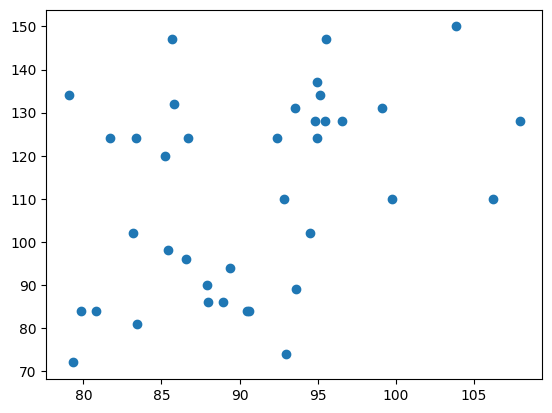

In [5]:
import matplotlib.pyplot as plt
plt.scatter(data['Brain'], data['PIQ'])

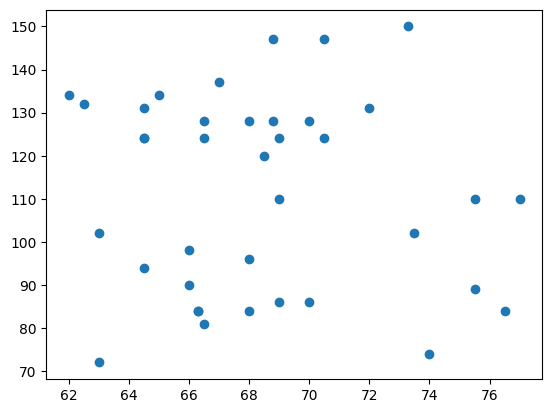

In [6]:
plt.scatter(data['Height'], data['PIQ'])

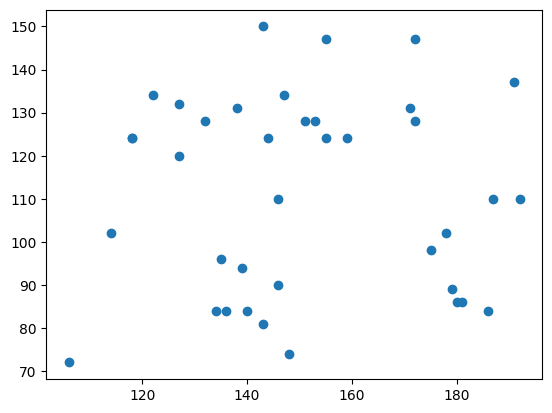

In [7]:
plt.scatter(data['Weight'], data['PIQ'])

In [14]:
import statsmodels.api as sm
y = data['PIQ']
X = data[['Brain', 'Height', 'Weight']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PIQ   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     4.741
Date:                Wed, 11 Dec 2024   Prob (F-statistic):            0.00722
Time:                        22:27:14   Log-Likelihood:                -165.25
No. Observations:                  38   AIC:                             338.5
Df Residuals:                      34   BIC:                             345.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.3536     62.971      1.768      0.086     -16.619     239.326
Brain          2.0604      0.563      3.657      0.001       0.915       3.205
Height        -2.7319      1.229     -2.222      0.033      -5.230      -0.233
Weight         0.0006      0.197      0.003      0.998      -0.400       0.401
==============================================================================
Omnibus:                        1.379   Durbin-Watson:                   1.827
Prob(Omnibus):                  0.502   Jarque-Bera (JB):                1.088
Skew:                           0.409   Prob(JB):                        0.580
Kurtosis:                       2.859   Cond. No.                     3.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

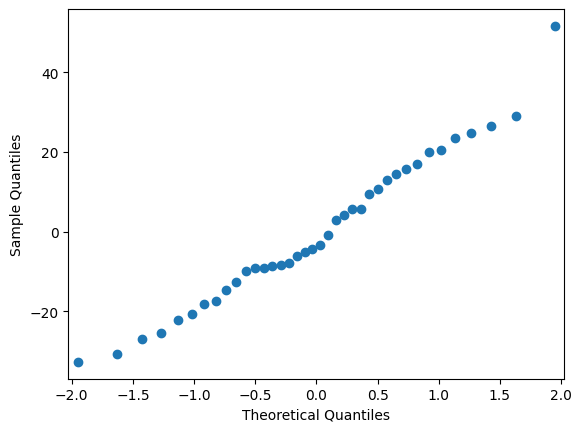

In [22]:
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
resi = model.resid
qqplot(resi)
plt.show()

In [20]:
# 獲取均方誤差 (MSE)
MSE = model.mse_resid  # 殘差均方和除以自由度

MSE

391.8178881224335

In [19]:
from scipy.stats import t
import numpy as np

In [25]:
coff = {
    'const':111.3536,
    'Brain':2.0604,
    'Height':-2.7319,
    'Weight':0.0006
}

subjects = [
    {'Brain':70, 'Height':60, 'Weight':160},
    {'Brain':90, 'Height':90, 'Weight':180}
    ]

n = 38
p = 4
df = n - p

t_critical = t.ppf(1-0.05, df)
MSE = 391.8179  # 從之前的 ANOVA 表格的 MSE 值
X = np.array([[1, sub['Brain'], sub['Height'], sub['Weight']] for sub in subjects])  # 包含常數項
predictions = []
for i in range(len(subjects)):
    # 計算預測點
    pred = (coff['const'] +
            coff['Brain'] * subjects[i]['Brain'] +
            coff['Height'] * subjects[i]['Height'] +
            coff['Weight'] * subjects[i]['Weight'])
    
    # 標準誤計算
    pred_std_err = np.sqrt(MSE * (1/n + (X[i] - np.mean(X, axis=0)).dot(np.linalg.pinv(X.T @ X)) @ (X[i] - np.mean(X, axis=0))))
    
    # 信賴區間
    ci_lower = pred - t_critical * pred_std_err
    ci_upper = pred + t_critical * pred_std_err
    
    # 保存結果
    predictions.append({
        'Prediction': pred,
        'CI Lower': ci_lower,
        'CI Upper': ci_upper
    })

In [26]:
predictions

[{'Prediction': 91.76360000000003,
  'CI Lower': 67.48131855291984,
  'CI Upper': 116.0458814470802},
 {'Prediction': 51.026599999999995,
  'CI Lower': 26.74431855291981,
  'CI Upper': 75.30888144708018}]

In [ ]:
import pandas as pd
from scipy.stats import t
import numpy as np

# 讀取上傳的 CSV 檔案
data = pd.read_csv('iqsize.csv')

# 定義應變項 Y 和自變項 X
Y = data['PIQ']
X = data[['Brain', 'Height', 'Weight']]

# 添加常數項以適應 statsmodels 的需求
X = sm.add_constant(X)

# 建立回歸模型
model = sm.OLS(Y, X).fit()

# 預測樣本數據 (Brain, Height, Weight)
samples = np.array([
    [1, 70, 60, 160],  # 常數項 + 样本1數據
    [1, 90, 90, 180]   # 常數項 + 样本2數據
])

# 計算預測值
predictions = model.get_prediction(samples)
summary_frame = predictions.summary_frame(alpha=0.1)  # 設定 90% 信賴區間

# 組織結果輸出
summary_frame[['mean', 'mean_ci_lower', 'mean_ci_upper']]


,mean,mean_ci_lower,mean_ci_upper
0,91.753124,68.180834,115.325415
1,51.013784,10.229807,91.797761


In [6]:
import statsmodels.formula.api as smf

In [23]:
data['Brain_x_Height'] = data['Brain'] * data['Height']
data['Height_x_Weight'] = data['Height'] * data['Weight']
data['Brain_x_Weight'] = data['Brain'] * data['Weight']


In [24]:
model = smf.ols(formula='PIQ ~ Brain + Height + Weight + Brain_x_Height + Height_x_Weight + Brain_x_Weight', data=data).fit()

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PIQ   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     2.396
Date:                Thu, 12 Dec 2024   Prob (F-statistic):             0.0511
Time:                        00:47:36   Log-Likelihood:                -164.65
No. Observations:                  38   AIC:                             343.3
Df Residuals:                      31   BIC:                             354.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        -103.1983    906.780     -0.114      0.910   -1952.589    1746.193
Brain              -1.8049     10.695     -0.169      0.867     -23.618      20.008
Height              5.1812     18.854      0.275      0.785     -33.272      43.634
Weight              1.4494      3.620      0.400      0.692      -5.934       8.833
Brain_x_Height      0.0041      0.192      0.021      0.983      -0.388       0.396
Height_x_Weight    -0.0521      0.053     -0.991      0.329      -0.159       0.055
Brain_x_Weight      0.0233      0.040      0.584      0.564      -0.058       0.105
==============================================================================
Omnibus:                        0.943   Durbin-Watson:                   1.799
Prob(Omnibus):                  0.624   Jarque-Bera (JB):                0.735
Skew:                           0.333   Prob(JB):                        0.693
Kurtosis:                       2.853   Cond. No.                     5.12e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.12e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

: 